# Finding illness metaphors: the whole pipeline, end to end

**Who this is for.** Anyone who wants to see exactly what the system does — project
members, clinical partners, PPI contributors, reviewers. No machine-learning background
assumed. Plain-language explanation first, code underneath.

**What you need.** Python and matplotlib. **No GPU, no API key, no internet.** Every number
and figure below is recomputed here from a data file that ships with the repository.

**Which data.** The public English corona collection — posts from two COVID illness
communities. We use it for the public walkthrough because the Dutch and Danish collections
are patient and participant data that cannot leave controlled infrastructure. The pipeline
is identical across all three; only the language of the prompts changes.

**What is and is not in the repository.** All *derived* data ships: every screen verdict,
score, rank, USAS code and span offset. The Reddit post text does **not** — the project
does not redistribute it, so the file carries post ids and character offsets instead. Text
*is* included for the two open-licensed sets used as known-good items (#ReframeCovid,
CC-licensed; the published Metaphor Menu). So every statistic is reproducible here, and
worked examples use only material we are licensed to quote.

## The problem in one paragraph

We want a *menu* of metaphors that patients actually use, so other patients can be offered
choices — is your illness a fight, a journey, an uninvited guest, a stone in your shoe? The
English Metaphor Menu was built by hand. We have far more text than anyone can read by
hand. So a computer proposes candidates and people decide. **The machine's job is to hand a
human a shortlist worth reading. It is not to decide what belongs in a menu.**

Two things must both be true for that to work: the shortlist has to contain the good
material, and it has to be short enough that someone actually reads it. This notebook
measures both.

In [1]:
import json, statistics as st
from collections import Counter, defaultdict
from pathlib import Path
import matplotlib.pyplot as plt

DATA = Path("data/corona_benchmark_dehydrated.json")   # ships in data/ next to this notebook
if not DATA.exists():
    raise SystemExit("run this notebook from the metaphor_search/ folder")

B = json.loads(DATA.read_text())
C = B["candidates"]
P = B["_pipeline"]

INK, MUT, LINE = "#1a1a1a", "#5f5f5f", "#d8d8d8"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8985"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": LINE, "text.color": INK,
                     "axes.labelcolor": MUT, "xtick.color": MUT, "ytick.color": MUT,
                     "figure.facecolor": "white", "axes.facecolor": "white"})

print(f"loaded {len(C):,} ranked candidates")
print("pipeline counts:", json.dumps(P))

loaded 1,503 ranked candidates
pipeline counts: {"segments": 1823, "mined_candidates": 2264, "cross_verified": 947, "screen_jobs": 1665, "nested_collapsed": 162, "ranked": 1503}


## Step 1 — Cut the text into small pieces

Long texts are split into chunks of two or three sentences, so every candidate arrives with
enough surrounding words for a person to judge it. 600 quality-filtered posts became
**1,823 chunks**.

Nothing clever happens here, but the choices are deliberate: the order is fixed, so
processing more text later *extends* the sample instead of reshuffling it, and results stay
comparable between runs.

## Step 2 — Two different models read every chunk

Each chunk goes to two models from **different families** — think of them as two readers
trained by different teams. Each is asked, in the language of the text:

> *Find all metaphorical expressions, including everyday ones.*

Note what is **not** asked. The models are not told to look for illness metaphors
specifically; they look for any figurative language. Narrowing to illness happens later, at
Step 4. (That is a design choice with a trade-off — see the last section.)

Both models run on our own machine. **No patient or participant text ever leaves it.**

Together they proposed **2,264 candidates** from the 1,823 chunks.

## Step 3 — Keep only what *both* models found

If just one model spots something, we drop it. If both independently point at the same
expression, we keep it. Two independent readers agreeing is evidence that something really
is figurative, and it costs no extra judgement.

This removed about 58% of the proposals: **2,264 → 947**.

What it *cannot* tell us is what the metaphor is **about**. *"This traffic is cancer"* is a
real metaphor that both models would happily agree on — and it is about traffic. That blind
spot is exactly why Step 4 exists.

In [2]:
# Known-good and known-bad items were hidden in the pile before screening, so we can ask
# where the system put things whose status we already knew.
labels = {"menu": "Menu items (known good)", "anchor": "ReframeCovid anchors",
          "pool": "Mined pool (unknown)", "probe": "Wrong-topic items (known bad)"}
counts = Counter(c["cls"] for c in C)

# ITEM level vs CANDIDATE level. One hidden item can yield several candidates (different
# spans of the same sentence), so counting candidates would let a single item vote several
# times. Every headline number here — and in the report — collapses each hidden item to its
# best-ranked candidate. Mined pool candidates are their own items.
def items_of(cls):
    if cls == "pool":
        return [c for c in C if c["cls"] == "pool"]
    best = {}
    for c in C:
        if c["cls"] != cls:
            continue
        k = c["plant_id"]
        if k not in best or c["rank"] < best[k]["rank"]:
            best[k] = c
    return list(best.values())

ITEMS = {k: items_of(k) for k in ("menu", "anchor", "pool", "probe")}
for k in ("menu", "anchor", "pool", "probe"):
    print(f"{labels[k]:32s} {len(ITEMS[k]):5,} items  ({counts[k]:5,} candidates)")

Menu items (known good)             17 items  (   60 candidates)
ReframeCovid anchors               124 items  (  368 candidates)
Mined pool (unknown)               946 items  (  946 candidates)
Wrong-topic items (known bad)       88 items  (  129 candidates)


## Step 4 — Three screens, each catching what the last one missed

Every surviving candidate faces three questions. Each is a separate model call, so each can
be inspected, changed or overruled on its own.

| Screen | The question | What it catches |
|---|---|---|
| **About illness?** | Is this really *about* the illness, treatment, body, being a patient? | *"this traffic is cancer"* — figurative, but about traffic |
| **About the lived experience?** | Is it about *living with* illness — coping, fear, hope, identity — rather than the disease as a medical object? | clinical description, measurements |
| **How menu-like?** | Score 0–10 against published Menu entries: vivid, personal, adoptable? | dead idioms score low, personal images high |

A fourth, smaller check labels each expression **everyday** or **vivid**, used only to break
ties. The model that *scores* comes from a **third** family, so no model rates its own
suggestion.

The chart below is the argument for having three screens rather than one.

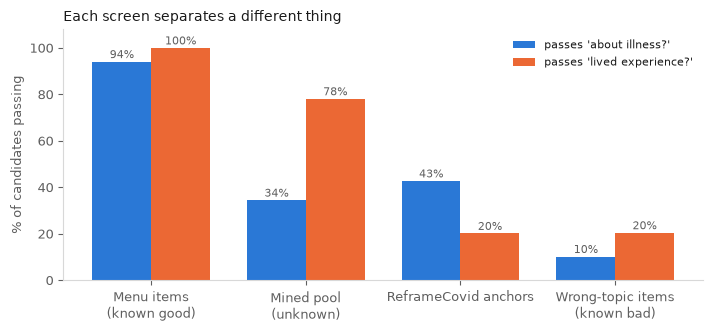

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
order = ["menu", "pool", "anchor", "probe"]
keep = [100*sum(1 for c in ITEMS[k] if c["verify"]=="keep")/len(ITEMS[k]) for k in order]
expe = [100*sum(1 for c in ITEMS[k] if c["experiential"])/len(ITEMS[k]) for k in order]
x = range(len(order)); w = 0.38
ax.bar([i-w/2 for i in x], keep, w, color=BLUE, label="passes 'about illness?'")
ax.bar([i+w/2 for i in x], expe, w, color=ORANGE, label="passes 'lived experience?'")
for i,(a,b) in enumerate(zip(keep, expe)):
    ax.text(i-w/2, a+1.5, f"{a:.0f}%", ha="center", fontsize=8, color=MUT)
    ax.text(i+w/2, b+1.5, f"{b:.0f}%", ha="center", fontsize=8, color=MUT)
ax.set_xticks(list(x)); ax.set_xticklabels([labels[k].replace(" (", "\n(") for k in order])
ax.set_ylabel("% of candidates passing"); ax.set_ylim(0, 108)
ax.legend(frameon=False, loc="upper right", fontsize=8)
for s in ("top","right"): ax.spines[s].set_visible(False)
ax.set_title("Each screen separates a different thing", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

**How to read that.** The known-bad items (*wrong-topic*) are the point. They are genuine
metaphors — two models agreed on them — but only about 10% survive the *about illness?*
screen. Agreement establishes that something is figurative; it cannot tell you what it is
about. That is one screen catching precisely what the previous one is blind to.

The ReframeCovid anchors are the interesting case. They pass *about illness?* at a healthy
rate but collapse on *lived experience* — because most of them reframe the pandemic as a
public event ("we are all in the same storm") rather than describing one person's illness.
The screen is not simply harsh: ordinary patient posts pass it at 78%.

## Step 5 — Sort the list

The final order is a cascade — like sorting a spreadsheet by several columns at once:

1. everything that passed **both** the illness and lived-experience questions
2. then everything that passed the illness question only
3. then everything that failed
4. within each group, by **menu-likeness score**, highest first
5. ties broken toward the **vivid** expression

Near-identical duplicates are merged here: if one model found *"a huge parenthesis closing
around you"* and the other *"parenthesis closing around you"*, that is one candidate, not
two. (A real bug, fixed 2026-08-19; it had inflated the lists by about a third.)

In [4]:
tiers = Counter(c["tier"] for c in C)
names = {0: "passed both screens", 1: "passed illness screen only", 2: "rejected"}
for t in (0,1,2):
    print(f"{names[t]:30s} {tiers[t]:5,}  ({100*tiers[t]/len(C):4.1f}%)")
print(f"\ndropped as near-duplicates before ranking: {P['nested_collapsed']}")

passed both screens              390  (25.9%)
passed illness screen only       127  ( 8.4%)
rejected                         986  (65.6%)

dropped as near-duplicates before ranking: 162


## Does the order actually work?

Here is the trap: we built the system, so if we simply read the top of our own list and
found it convincing, that would prove nothing.

Instead we **hid items whose status we already knew** inside the pile — published Menu
entries as known-good, and figurative disease-mentions about non-illness topics as
known-bad. They were pushed through the same extraction step as everything else, so they
are indistinguishable in format from ordinary candidates. Then we ask one question:

> **Did the system push the known-good items up, and the known-bad ones down?**

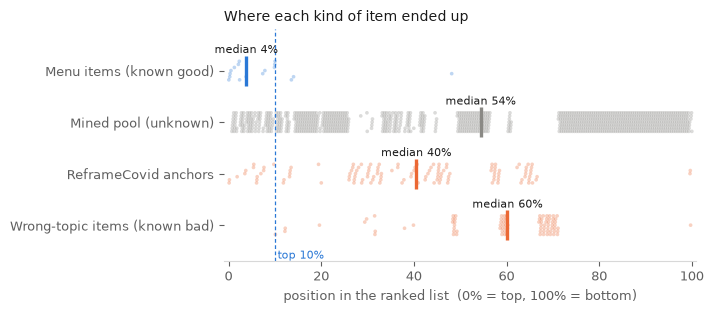

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
N = len(C)
colors = {"menu": BLUE, "pool": GREY, "anchor": ORANGE, "probe": ORANGE}
for i, k in enumerate(order):
    pos = [100*c["rank"]/N for c in ITEMS[k]]
    y = len(order)-i
    ax.scatter(pos, [y+0.06*((j%7)-3) for j in range(len(pos))], s=7, alpha=.30,
               color=colors[k], edgecolors="none")
    m = st.median(pos)
    ax.plot([m],[y], "|", ms=22, mew=2.4, color=colors[k])
    ax.text(m, y+0.34, f"median {m:.0f}%", ha="center", fontsize=8, color=INK)
ax.axvline(10, color=BLUE, ls=(0,(3,2)), lw=.9)
ax.text(10.6, 0.35, "top 10%", color=BLUE, fontsize=8)
ax.set_yticks(range(1, len(order)+1)); ax.set_yticklabels([labels[k] for k in reversed(order)])
ax.set_xlabel("position in the ranked list  (0% = top, 100% = bottom)")
ax.set_xlim(-1, 101); ax.set_ylim(0.3, len(order)+0.8)
for s in ("top","right","left"): ax.spines[s].set_visible(False)
ax.set_title("Where each kind of item ended up", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

In [6]:
print(f"{'':32s} {'n':>5s} {'median rank':>12s} {'top 10%':>9s} {'bottom half':>12s}")
for k in order:
    rk = sorted(c["rank"] for c in ITEMS[k])
    print(f"{labels[k]:32s} {len(rk):5,} {int(st.median(rk)):12,} "
          f"{100*sum(1 for x in rk if x<=N*.1)/len(rk):8.1f}% "
          f"{100*sum(1 for x in rk if x>N*.5)/len(rk):11.1f}%")

                                     n  median rank   top 10%  bottom half
Menu items (known good)             17           57     76.5%         0.0%
Mined pool (unknown)               946          817     10.1%        57.0%
ReframeCovid anchors               124          608     11.3%        29.0%
Wrong-topic items (known bad)       88          904      0.0%        73.9%


## A correction: the scorer was shown some of the answers

The menu-likeness screen asks "how strongly does this resemble entries in the published
Metaphor Menu?" — and then shows it several Menu entries as examples. The planted known-good
items are *also* Menu entries. Where those overlap, a plant is being scored partly against
itself.

We found this on 2026-08-19, after the results above were first written up. The rule since
then: **a planted entry that the scoring prompt names is not considered** — its candidates
are removed before ranking, so every number in this notebook is computed without them. The
file records which entries that were. Because the prompt's examples are paraphrases rather
than quotations, the correspondence is fixed by hand per language
(`metaphor_extraction/evals/plant_leak.py`), not by string matching.

In [ ]:
ex = B["_excluded_quoted_in_prompt"]
print(f"planted Menu entries not considered (quoted in the scoring prompt): {ex['entries']}")
print(f"candidate rows removed before ranking: {ex['candidate_rows_dropped']}\n")
rk = sorted(c["rank"] for c in ITEMS["menu"])
print(f"{'considered planted entries':26s} n={len(rk):2d}  median rank {int(st.median(rk)):,} of {N:,}  "
      f"top 10% {100*sum(1 for x in rk if x<=N*0.1)/len(rk):.1f}%  "
      f"mean score {sum(c['score'] for c in ITEMS['menu'])/len(rk):.2f}")
print()
print("The same rule on the project's other corpora: Danish drops 6 of 15 planted entries (its")
print("anchors are a different set), Dutch drops 2 of 15 (its anchors are the English set")
print("translated). Held-out figures are the only ones reported anywhere.")

## The practical question: how much would a reviewer have to read?

Ranking only matters if it lets a person stop early. This curve answers that directly: read
the top *x*% of the list, and what share of the known-good items have you already seen?

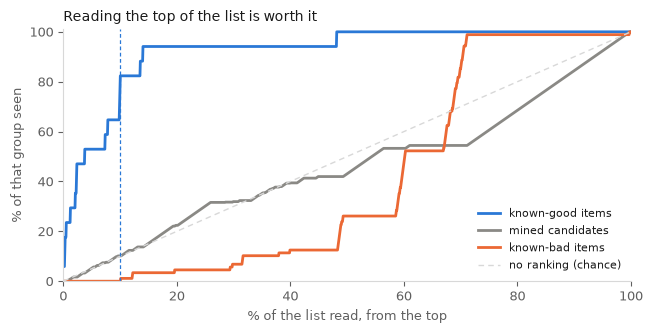

read the top  5% (  75 of 1,503) ->  52.9% of known-good items seen
read the top 10% ( 150 of 1,503) ->  76.5% of known-good items seen
read the top 25% ( 375 of 1,503) ->  94.1% of known-good items seen


In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
N = len(C)
for k, lab in (("menu", "known-good items"), ("pool", "mined candidates"),
               ("probe", "known-bad items")):
    rk = sorted(c["rank"] for c in ITEMS[k])
    xs = [100*i/N for i in range(1, N+1)]
    ys = [100*sum(1 for r in rk if r<=i)/len(rk) for i in range(1, N+1)]
    ax.plot(xs, ys, lw=2, color=colors[k], label=lab)
ax.plot([0,100],[0,100], lw=1, ls=(0,(4,3)), color=LINE, label="no ranking (chance)")
ax.axvline(10, color=BLUE, ls=(0,(3,2)), lw=.9)
ax.set_xlabel("% of the list read, from the top"); ax.set_ylabel("% of that group seen")
ax.set_xlim(0,100); ax.set_ylim(0,101); ax.legend(frameon=False, fontsize=8, loc="lower right")
for s in ("top","right"): ax.spines[s].set_visible(False)
ax.set_title("Reading the top of the list is worth it", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

rk = sorted(c["rank"] for c in ITEMS["menu"])
for frac in (5, 10, 25):
    cut = N*frac/100
    print(f"read the top {frac:2d}% ({int(cut):4,} of {N:,}) -> "
          f"{100*sum(1 for r in rk if r<=cut)/len(rk):5.1f}% of known-good items seen")

## What the candidates actually look like

Only the open-licensed material is quoted here: #ReframeCovid entries (CC-licensed,
attributed) and published Metaphor Menu items. Mined Reddit candidates are **not** shown —
the file ships their ranks, verdicts and offsets, not their text.

In [9]:
quotable = [c for c in C if "phrase" in c]
print(f"{len(quotable)} candidates carry quotable text\n")
top = sorted([c for c in quotable if c["cls"]=="menu"], key=lambda c: c["rank"])[:5]
for c in top:
    print(f"rank {c['rank']:4d} | score {c['score']:.0f} | {c['register']:12s} | "
          f"{c['phrase'][:70]}")
print()
low = sorted([c for c in quotable if c["cls"]=="anchor"], key=lambda c: -c["rank"])[:5]
print("ReframeCovid anchors the ranking pushed DOWN (tenor is public discourse, not lived illness):")
for c in low:
    print(f"rank {c['rank']:4d} | experiential={str(c['experiential']):5s} | {c['phrase'][:70]}")

428 candidates carry quotable text

rank    1 | score 9 | vivid        | a relationship where I am forced to live with my disease day in, day o
rank    4 | score 8 | vivid        | Like a scary fairground ride
rank    5 | score 8 | vivid        | invite my cancer to leave
rank    6 | score 8 | vivid        | parking itself in the back room
rank    7 | score 8 | vivid        | cancer arrived as an unwelcome lodger

ReframeCovid anchors the ranking pushed DOWN (tenor is public discourse, not lived illness):
rank 1498 | experiential=False | Boris Johnson is Britian
rank 1497 | experiential=False | Anti-China virus
rank 1003 | experiential=False | restarts the economy
rank 1002 | experiential=False | passed this test
rank 1001 | experiential=False | next steps


## Which source domains do the metaphors come from?

Each candidate can be tagged with the semantic field of its **image** — what illness is
being compared *to*. This is the "what is illness framed as?" question the project exists
to answer, and it took two attempts to get a usable answer.

**First attempt (not usable).** The extraction prompt asked for the USAS category of the
image and offered two examples (`e.g. W4, M1`). Those two codes then accounted for 92% of
all codes returned, and up to 86% in the Danish questionnaire. The models were copying the
examples — prompt anchoring — so those codes measured the prompt, not the patients.

**Second attempt (what the demo pages use).** The top 800 candidates of each corpus were
re-tagged in a separate pass with the *complete* USAS inventory (232 codes) and no
examples, by two local model families independently; the pages show the gemma4 tags.
Codes are grouped into analyst categories in the manner of Demmen et al. (Journey,
Violence, Sports/Games, …). Because USAS stops at "warfare" and "sports", the pages add
finer layers — the head word of the image, its WordNet hypernym, and a short concept named
in context by a local model, normalised by embedding similarity — so *war* and *fight*, or
*boxing* and *marathon*, can be told apart.

The cell below reads those tags for the public English benchmark. Two things to notice:
Journey is the largest *named* category, as in the Danish and Dutch corpora (a sizeable share of images fall outside the named categories altogether); and the two model
families agree on the exact code far less often than on the category — a reason the pages
show one family and label it.


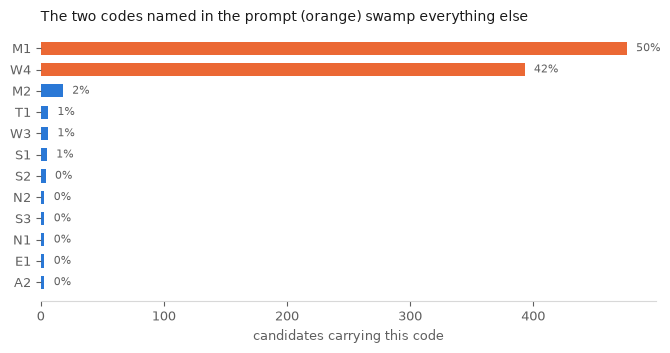

codes returned              : 946
the two prompt examples     : 869  (91.9%)
everything else             : 77  (8.1%)

The residue — cases where the model overrode the anchor — is the only part that may
carry signal, and it is too small and too self-selected to analyse:
   M2     18
   T1      6
   W3      6
   S1      5
   S2      4
   N2      3
   S3      3
   N1      3
   E1      3
   A2      3
   B1      3


In [10]:
import json
from pathlib import Path
DATA = Path("data")
tags = [json.loads(l) for l in (DATA / "corona_vehicle_tags_v3_gemma4-31b.jsonl").read_text().splitlines() if l.strip()]
tags = [t for t in tags if "id" in t]
cats = Counter(t["analyst"] for t in tags if t.get("analyst"))
tot = sum(cats.values())

fig, ax = plt.subplots(figsize=(6.8, 3.6))
top = cats.most_common(10)
names = [k for k, _ in top][::-1]; vals = [v for _, v in top][::-1]
ax.barh(names, vals, color=BLUE, height=.62)
for i, v in enumerate(vals):
    ax.text(v + tot*0.005, i, f"{100*v/tot:.0f}%", va="center", fontsize=8, color=MUT)
ax.set_xlabel("candidates (top 800) whose image falls in this category — gemma4 re-tag")
for sp in ("top","right","left"): ax.spines[sp].set_visible(False)
ax.set_title("Source domains after the corrected re-tag (analyst categories)", loc="left", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

# the finer layers: what the model actually called the image, inside the two biggest categories
layers = {json.loads(l)["id"]: json.loads(l) for l in (DATA / "corona_vehicle_layers.jsonl").read_text().splitlines() if l.strip()}
for cat in [k for k, _ in cats.most_common(3) if not k.startswith("Other")][:2]:
    ids = [t["id"] for t in tags if t.get("analyst") == cat]
    concepts = Counter(layers[i].get("llm_c1") for i in ids if i in layers and layers[i].get("llm_c1"))
    print(f"{cat}: " + ", ".join(f"{c} ({n})" for c, n in concepts.most_common(8)))
print(f"\n{tot} tagged candidates; categories: {len(cats)}. The full table, clickable, is on the demo's stage-3 page.")


## What this does **not** tell you

Please read this before quoting any number above.

- **No patient has judged any of it.** "Good" means good *by the system's criteria*.
  Whether these metaphors help patients is a question for patients and PPI contributors,
  and that step has not happened.
- **The hidden-item test depends on the company they keep.** Positions are relative to the
  surrounding pool. In the Danish collection, adding a richer source made the hidden items
  *appear* to do worse — not because the system changed, but because hundreds of genuinely
  good candidates now competed for the same top slots.
- **Scores are not calibrated.** They cluster low. Trust the *order*, not the number.
- **17 hidden good items** is a real signal but a small one.
- **The hidden items are published/translated text**, which may read more formally than
  spontaneous writing. If a human can spot them by style rather than quality, the test is
  weaker than it looks. That is what the blinded human session is for.

## One design choice worth understanding

The project's central idea is to fix the illness domain (USAS **B2, Health and disease**) as
the topic and ask what it is compared to. The runs shown here arrive from the other
direction: they extract metaphors **openly**, then screen for the illness topic afterwards.

- **Asking for B2 up front** → shorter, tighter list; the model does the narrowing.
- **Extracting openly, then screening** → longer list, but it catches cases where the
  illness is implied rather than named, and the narrowing lives in a screen you can read,
  adjust and re-run without re-processing all the text.

The evidence here is for the second route. Which ranks better **has not been tested**, and
saying so is more useful than guessing.

---

*Full technical report: `papers/RANKER_EVAL_REPORT.md`. Plain-language summary:
`papers/HOW_IT_WORKS_PLAIN.md`. Reproduction on your own data:
`metaphor_extraction/evals/REPRODUCE.md`. Corrections and how to re-verify them:
`papers/RANKER_CORRECTIONS_2026-08-19.md`.*